In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download required NLTK data
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
except:
    pass

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('english_news.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (57169, 5)

First few rows:


,publishedAt,title,source,description,url
0,2020-11-02 00:22:25+00:00,Ant Group: How it became a financial giant,BBC News,As China's Ant Group prepares for its stock ma...,https://www.bbc.co.uk/news/av/business-54746206
1,2020-11-02 00:25:38+00:00,US election 2020: Why does the vote matter to ...,BBC News,How could a Trump or a Biden win have an impac...,https://www.bbc.co.uk/news/election-us-2020-54...
2,2020-11-02 12:03:10+00:00,US is leaving the Paris Accord: How that will ...,ABC News,The U.S. will officially withdraw from the Par...,https://abcnews.go.com/US/us-leaving-paris-agr...
3,2020-11-02 14:16:20+00:00,The Countdown: Lady Gaga gets drawn in as camp...,BBC News,The latest US election news in four sentences ...,https://www.bbc.co.uk/news/election-us-2020-54...
4,2020-11-06 17:39:26+00:00,UK energy plant to use liquid air,BBC News,The 50MW facility near Manchester hopes to sto...,https://www.bbc.co.uk/news/business-54841528


In [5]:
# Data preprocessing
df['publishedAt'] = pd.to_datetime(df['publishedAt'])
df['date'] = df['publishedAt'].dt.date
df['hour'] = df['publishedAt'].dt.hour
df['year_month'] = df['publishedAt'].dt.to_period('M')

print("Data info:")
print(df.info())
print(f"\nDate range: {df['publishedAt'].min()} to {df['publishedAt'].max()}")
print(f"\nUnique sources: {df['source'].nunique()}")
print(f"\nSource counts:")
print(df['source'].value_counts())


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57169 entries, 0 to 57168
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   publishedAt  57169 non-null  datetime64[ns, UTC]
 1   title        57168 non-null  object             
 2   source       57169 non-null  object             
 3   description  56448 non-null  object             
 4   url          57169 non-null  object             
 5   date         57169 non-null  object             
 6   hour         57169 non-null  int32              
 7   year_month   57169 non-null  period[M]          
dtypes: datetime64[ns, UTC](1), int32(1), object(5), period[M](1)
memory usage: 3.3+ MB
None

Date range: 2020-11-02 00:22:25+00:00 to 2025-10-31 10:06:03+00:00

Unique sources: 11

Source counts:
source
ABC News                   16568
BBC News                    8401
USA Today                   7056
NBC News                    6476
CNN  

/var/folders/g9/0v3_zgv50lx0t6nwqgvc6d080000gn/T/ipykernel_4475/1096297928.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['publishedAt'].dt.to_period('M')


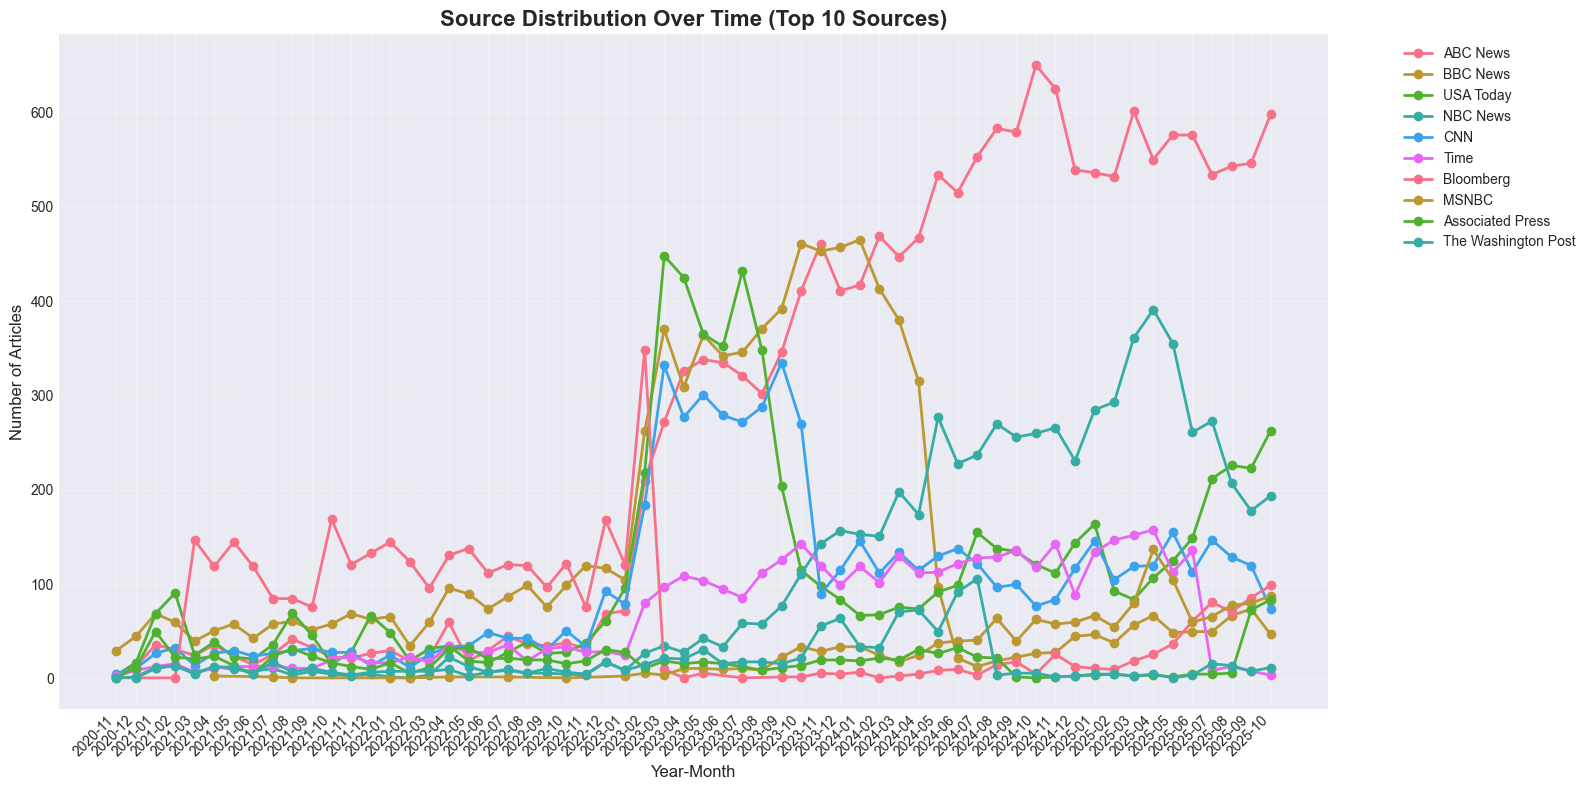

In [6]:
# 1. Source distribution over time
source_time = df.groupby(['year_month', 'source']).size().reset_index(name='count')
source_time['year_month'] = source_time['year_month'].astype(str)

# Get top sources for better visualization
top_sources = df['source'].value_counts().head(10).index.tolist()
source_time_filtered = source_time[source_time['source'].isin(top_sources)]

plt.figure(figsize=(16, 8))
for source in top_sources:
    source_data = source_time_filtered[source_time_filtered['source'] == source]
    plt.plot(source_data['year_month'], source_data['count'], marker='o', label=source, linewidth=2)

plt.title('Source Distribution Over Time (Top 10 Sources)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


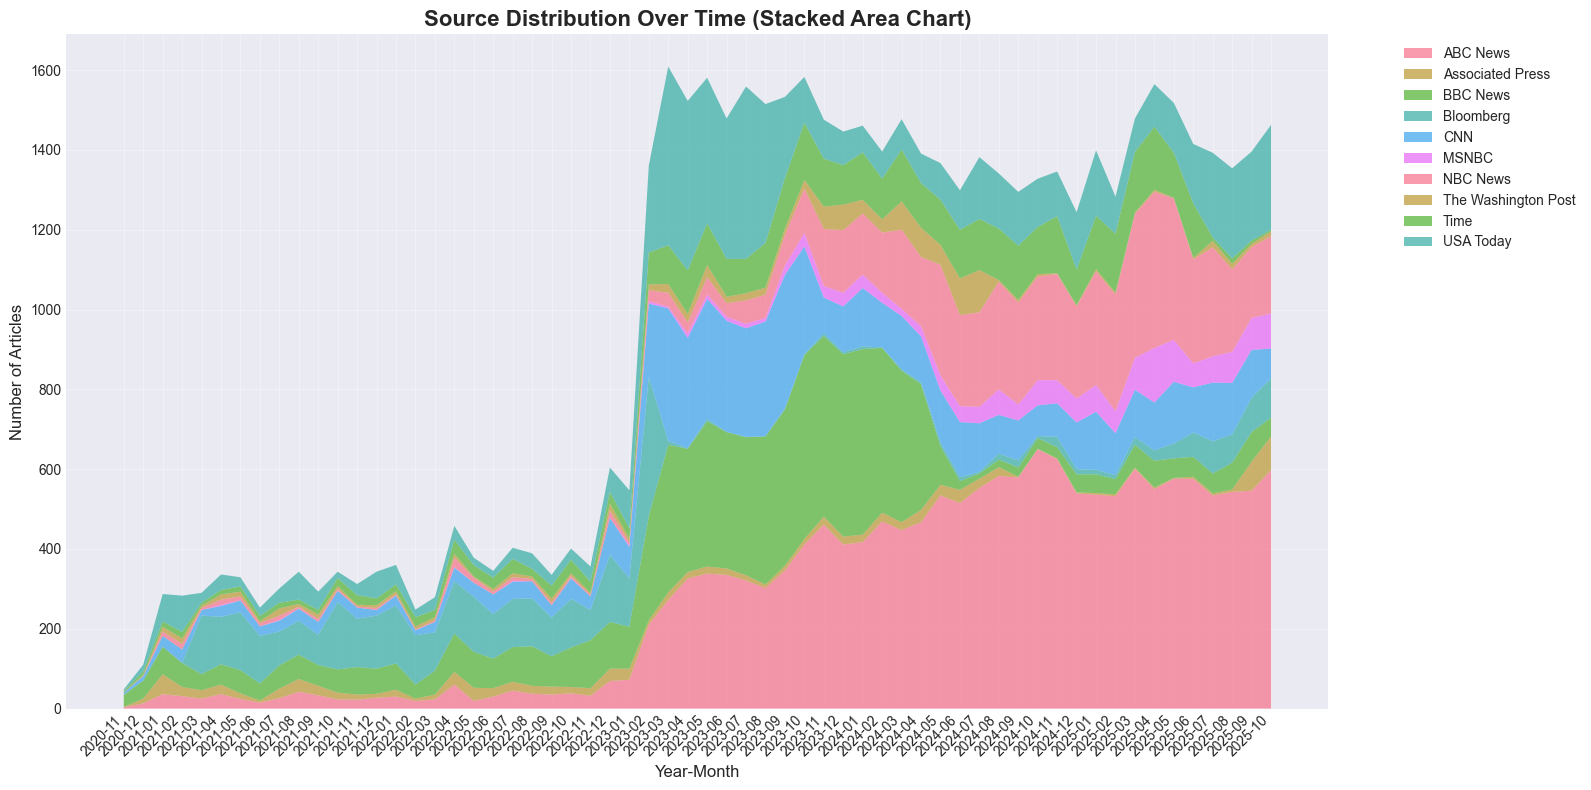

In [7]:
# Alternative: Stacked area chart for source distribution over time
source_time_pivot = source_time_filtered.pivot(index='year_month', columns='source', values='count').fillna(0)

plt.figure(figsize=(16, 8))
plt.stackplot(source_time_pivot.index, *source_time_pivot.values.T, 
              labels=source_time_pivot.columns, alpha=0.7)
plt.title('Source Distribution Over Time (Stacked Area Chart)', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


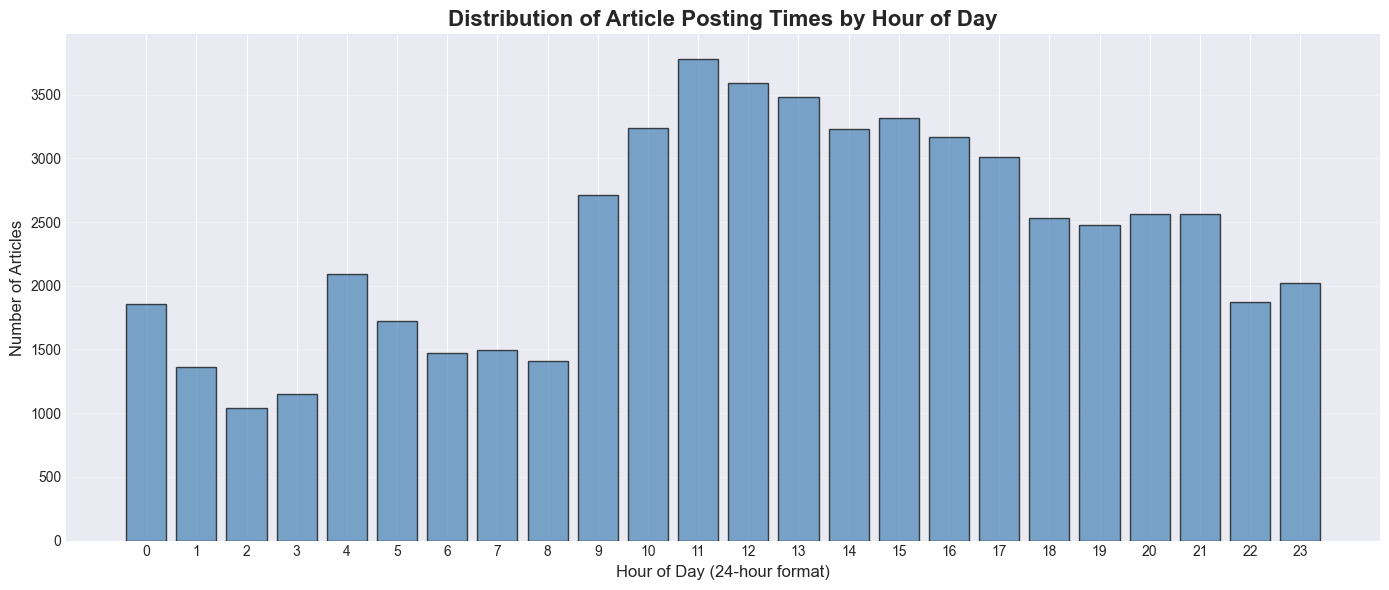


Peak posting hours:
hour
0    1857
1    1361
2    1043
3    1147
4    2089
Name: count, dtype: int64

Least active hours:
hour
19    2480
20    2567
21    2563
22    1876
23    2018
Name: count, dtype: int64


In [8]:
# 2. Time of posting (hour in a day)
hour_dist = df['hour'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.bar(hour_dist.index, hour_dist.values, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Article Posting Times by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(range(24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nPeak posting hours:")
print(hour_dist.head(5))
print(f"\nLeast active hours:")
print(hour_dist.tail(5))


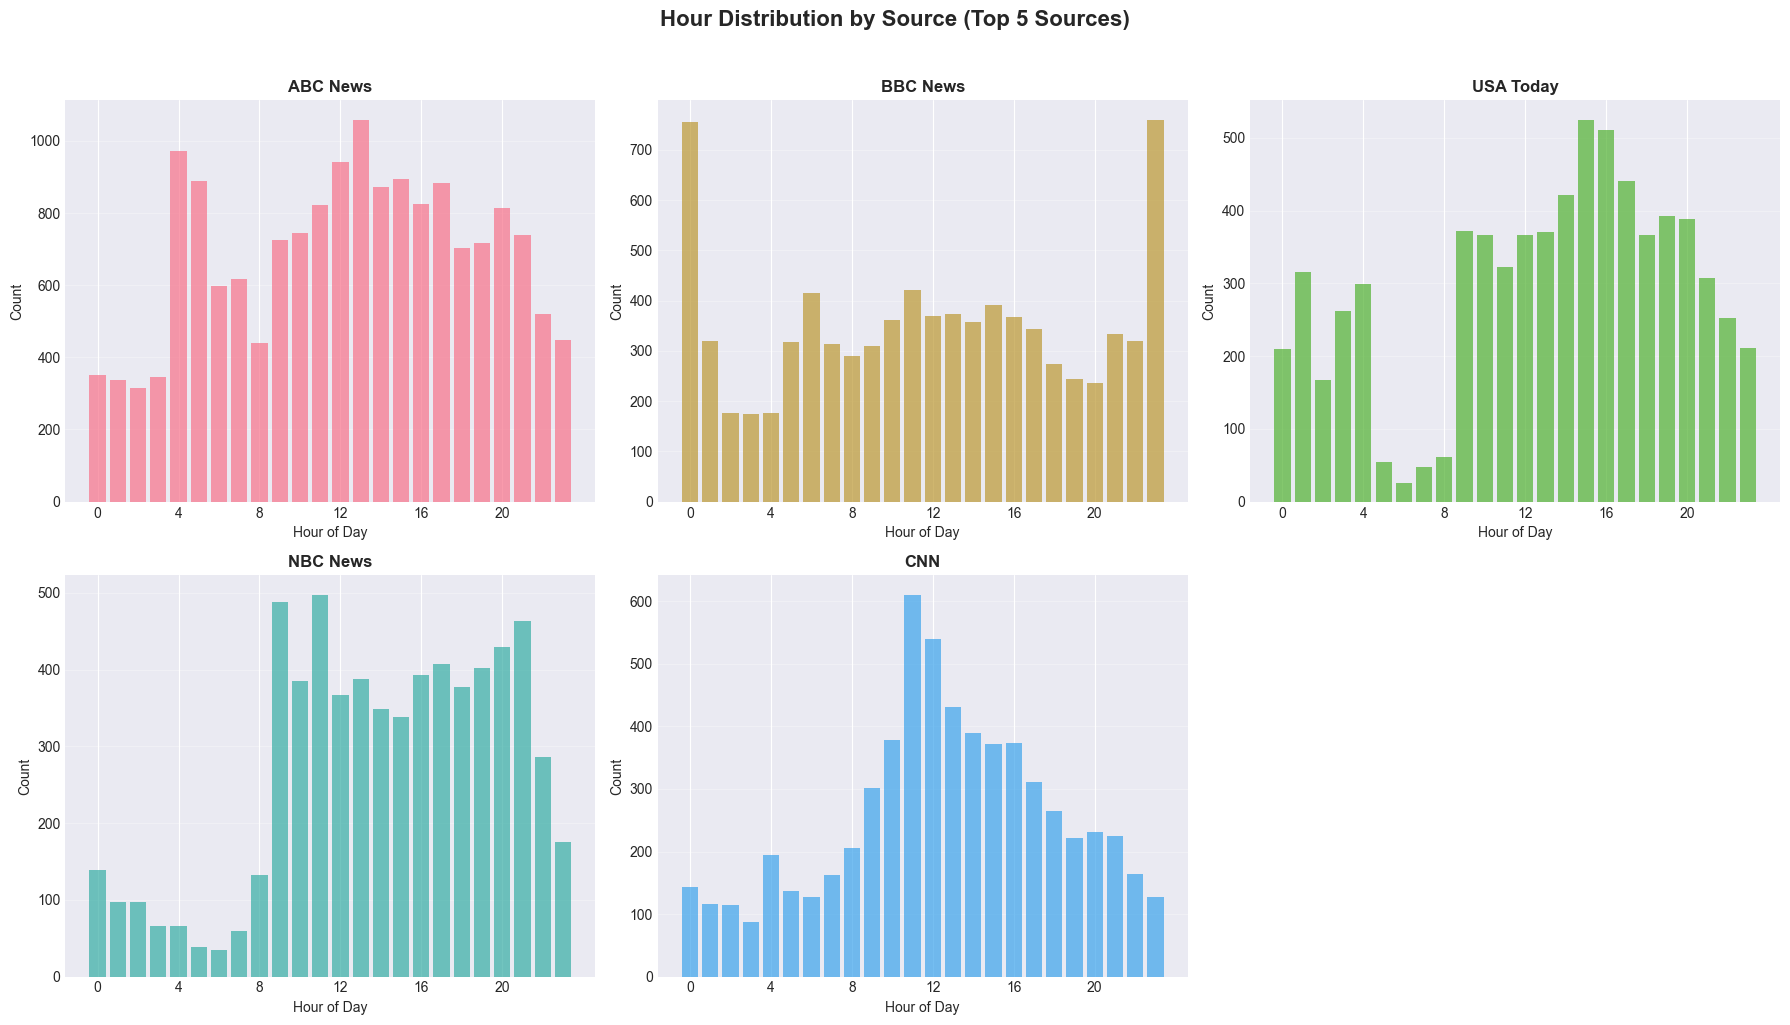

In [9]:
# Hour distribution by source (top 5 sources)
top_5_sources = df['source'].value_counts().head(5).index.tolist()
hour_by_source = df[df['source'].isin(top_5_sources)].groupby(['source', 'hour']).size().reset_index(name='count')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, source in enumerate(top_5_sources):
    source_data = hour_by_source[hour_by_source['source'] == source]
    axes[idx].bar(source_data['hour'], source_data['count'], color=f'C{idx}', alpha=0.7)
    axes[idx].set_title(f'{source}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Hour of Day')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticks(range(0, 24, 4))
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Hour Distribution by Source (Top 5 Sources)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# ============================================
# TOPIC MODELING WITH BERTOPIC
# ============================================

# Install required packages (uncomment if needed)
# !pip install bertopic[visualization] sentence-transformers umap-learn hdbscan

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
import warnings
warnings.filterwarnings('ignore')

print("BERTopic libraries imported successfully!")


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERTopic libraries imported successfully!


In [16]:
# Prepare text data for topic modeling
# Combine title and description, remove missing values
df_topic = df.copy()
df_topic['combined_text'] = df_topic.apply(
    lambda row: f"{row['title']} {row['description']}" 
    if pd.notna(row['title']) and pd.notna(row['description']) 
    else (row['title'] if pd.notna(row['title']) else str(row['description']) if pd.notna(row['description']) else ''),
    axis=1
)

# Remove empty strings
df_topic = df_topic[df_topic['combined_text'].str.strip() != ''].copy()
df_topic = df_topic[df_topic['combined_text'].str.len() > 20].copy()  # Minimum length

print(f"Articles prepared for topic modeling: {len(df_topic)}")
print(f"\nSample text (first 200 chars):")
print(df_topic['combined_text'].iloc[0][:200])


Articles prepared for topic modeling: 57168

Sample text (first 200 chars):
Ant Group: How it became a financial giant As China's Ant Group prepares for its stock market debut, we look at how it established its empire.


In [17]:
# Sample data for faster initial modeling (optional - comment out to use full dataset)
# For faster exploration, we'll use a sample. Set SAMPLE_SIZE = None to use all data
SAMPLE_SIZE = None  # Set to None to use all data

if SAMPLE_SIZE and len(df_topic) > SAMPLE_SIZE:
    df_sample = df_topic.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Using sample of {SAMPLE_SIZE} articles for faster processing")
else:
    df_sample = df_topic
    print(f"Using all {len(df_sample)} articles")

# Extract documents
documents = df_sample['combined_text'].tolist()
print(f"\nTotal documents: {len(documents)}")
print(f"Average document length: {np.mean([len(doc) for doc in documents]):.1f} characters")


Using all 57168 articles

Total documents: 57168
Average document length: 216.6 characters


In [18]:
# Initialize BERTopic with optimized settings for news articles
# Using a smaller embedding model for faster processing
print("Initializing BERTopic model...")
print("This may take a few minutes...")

# Use a lightweight embedding model for faster processing
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Configure dimensionality reduction and clustering
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words=10,
    verbose=True,
    language='english'
)

# Fit the model
print("\nFitting the model to documents...")
topics, probs = topic_model.fit_transform(documents)

print(f"\nModel training completed!")
print(f"Number of topics discovered: {len(set(topics)) - (1 if -1 in topics else 0)}")
if -1 in topics:
    print(f"Outliers (topic -1): {topics.count(-1)} documents")


Initializing BERTopic model...
This may take a few minutes...


2025-10-31 12:24:50,808 - BERTopic - Embedding - Transforming documents to embeddings.



Fitting the model to documents...


Batches: 100%|██████████| 1787/1787 [00:50<00:00, 35.27it/s]
2025-10-31 12:25:41,922 - BERTopic - Embedding - Completed ✓
2025-10-31 12:25:41,922 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-31 12:26:26,211 - BERTopic - Dimensionality - Completed ✓
2025-10-31 12:26:26,213 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR


Model training completed!
Number of topics discovered: 172
Outliers (topic -1): 20257 documents


In [19]:
# Get topic information
topic_info = topic_model.get_topic_info()

print("Topic Overview:")
print("=" * 80)
print(topic_info.head(20))

# Filter out outlier topic (-1) for better visualization
topics_to_show = topic_info[topic_info['Topic'] != -1]

print(f"\n\nTotal topics discovered (excluding outliers): {len(topics_to_show)}")
print(f"Documents in topics: {topics_to_show['Count'].sum()}")
print(f"Outliers (unassigned): {topic_info[topic_info['Topic'] == -1]['Count'].values[0] if len(topic_info[topic_info['Topic'] == -1]) > 0 else 0}")


Topic Overview:
    Topic  Count                                  Name  \
0      -1  20257                      -1_to_of_the_and   
1       0   2154                0_nfl_colts_free_draft   
2       1   1392    1_ukraine_russia_ukrainian_russian   
3       2   1209         2_electric_tesla_car_vehicles   
4       3    982              3_music_film_movie_swift   
5       4    935       4_cup_league_manchester_england   
6       5    921         5_mortgage_housing_home_rates   
7       6    841            6_stores_sales_meat_retail   
8       7    799           7_gaza_israel_hamas_israeli   
9       8    706           8_football_college_state_vs   
10      9    693          9_sunak_labour_starmer_rishi   
11     10    641            10_nba_lakers_celtics_nets   
12     11    590         11_explosion_fire_injured_gas   
13     12    566     12_china_chinese_property_economy   
14     13    555  13_ai_artificial_intelligence_openai   
15     14    549             14_deals_best_shop_amazon  

In [20]:
# Display top topics with their key words
print("\n\nTop Topics and Their Keywords:")
print("=" * 80)

for idx, row in topics_to_show.head(15).iterrows():
    topic_id = row['Topic']
    count = row['Count']
    name = row['Name']
    
    # Get top words for this topic
    top_words = topic_model.get_topic(topic_id)
    words_str = ", ".join([word for word, score in top_words[:8]])
    
    print(f"\nTopic {topic_id}: {name}")
    print(f"  Articles: {count} ({count/len(documents)*100:.1f}%)")
    print(f"  Key words: {words_str}")




Top Topics and Their Keywords:

Topic 0: 0_nfl_colts_free_draft
  Articles: 2154 (3.8%)
  Key words: nfl, colts, free, draft, bears, vs, bengals, chiefs

Topic 1: 1_ukraine_russia_ukrainian_russian
  Articles: 1392 (2.4%)
  Key words: ukraine, russia, ukrainian, russian, putin, kyiv, war, zelenskyy

Topic 2: 2_electric_tesla_car_vehicles
  Articles: 1209 (2.1%)
  Key words: electric, tesla, car, vehicles, vehicle, ev, cars, auto

Topic 3: 3_music_film_movie_swift
  Articles: 982 (1.7%)
  Key words: music, film, movie, swift, taylor, her, album, hollywood

Topic 4: 4_cup_league_manchester_england
  Articles: 935 (1.6%)
  Key words: cup, league, manchester, england, chelsea, liverpool, premier, manager

Topic 5: 5_mortgage_housing_home_rates
  Articles: 921 (1.6%)
  Key words: mortgage, housing, home, rates, average, homes, rate, homebuyers

Topic 6: 6_stores_sales_meat_retail
  Articles: 841 (1.5%)
  Key words: stores, sales, meat, retail, walmart, bankruptcy, food, shoppers

Topic 7:

In [25]:
# Add topic assignments to dataframe for further analysis
df_sample['topic'] = topics
df_sample['topic_probability'] = probs if probs is not None else [None] * len(topics)

# Analyze topics by source
print("\n\nTopic Distribution by News Source:")
print("=" * 80)

topic_by_source = df_sample.groupby(['source', 'topic']).size().reset_index(name='count')
top_topics = topics_to_show.head(10)['Topic'].tolist()

for source in df_sample['source'].unique()[:5]:  # Top 5 sources
    source_data = topic_by_source[topic_by_source['source'] == source]
    source_topics = source_data[source_data['topic'].isin(top_topics)]
    
    print(f"\n{source}:")
    for _, row in source_topics.sort_values('count', ascending=False).head(5).iterrows():
        topic_id = row['topic']
        count = row['count']
        topic_name = topic_info[topic_info['Topic'] == topic_id]['Name'].values[0] if len(topic_info[topic_info['Topic'] == topic_id]) > 0 else "Unknown"
        print(f"  Topic {topic_id} ({topic_name}): {count} articles")




Topic Distribution by News Source:

BBC News:
  Topic 4 (4_cup_league_manchester_england): 874 articles
  Topic 9 (9_sunak_labour_starmer_rishi): 512 articles
  Topic 1 (1_ukraine_russia_ukrainian_russian): 321 articles
  Topic 5 (5_mortgage_housing_home_rates): 210 articles
  Topic 7 (7_gaza_israel_hamas_israeli): 196 articles

ABC News:
  Topic 1 (1_ukraine_russia_ukrainian_russian): 489 articles
  Topic 2 (2_electric_tesla_car_vehicles): 381 articles
  Topic 3 (3_music_film_movie_swift): 275 articles
  Topic 7 (7_gaza_israel_hamas_israeli): 194 articles
  Topic 5 (5_mortgage_housing_home_rates): 179 articles

CNN:
  Topic 2 (2_electric_tesla_car_vehicles): 213 articles
  Topic 5 (5_mortgage_housing_home_rates): 195 articles
  Topic 6 (6_stores_sales_meat_retail): 161 articles
  Topic 1 (1_ukraine_russia_ukrainian_russian): 138 articles
  Topic 7 (7_gaza_israel_hamas_israeli): 109 articles

Time:
  Topic 3 (3_music_film_movie_swift): 201 articles
  Topic 7 (7_gaza_israel_hamas_isra

In [26]:
# Show representative documents for top topics
print("\n\nRepresentative Documents for Top Topics:")
print("=" * 80)

for topic_id in topics_to_show.head(5)['Topic'].tolist():
    print(f"\n{'='*80}")
    print(f"Topic {topic_id}: {topic_info[topic_info['Topic'] == topic_id]['Name'].values[0]}")
    print(f"{'='*80}")
    
    # Get representative documents
    representative_docs = topic_model.get_representative_docs(topic_id)
    
    # Also show some actual documents from our dataset
    topic_docs = df_sample[df_sample['topic'] == topic_id]
    
    if len(topic_docs) > 0:
        print(f"\nSample documents from this topic:")
        for idx, (_, row) in enumerate(topic_docs.head(3).iterrows()):
            print(f"\n  Document {idx+1}:")
            print(f"  Source: {row['source']}")
            print(f"  Title: {row['title']}")
            print(f"  Description: {str(row['description'])[:150]}...")
            if idx < 2:  # Only show first 2 full examples
                print()




Representative Documents for Top Topics:

Topic 0: 0_nfl_colts_free_draft

Sample documents from this topic:

  Document 1:
  Source: USA Today
  Title: How to watch 49ers-Cardinals game on Saturday
  Description: The Cardinals' home game with the 49ers is on Amazon Prime Video on Saturday...


  Document 2:
  Source: USA Today
  Title: Texans vs. Bengals: Time, TV schedule and streaming info for Week 16
  Description: The Houston Texans take on the Cincinnati Bengals Sunday at 12:00 p.m. CT at NRG Stadium. Find out how to catch the game on a variety of media....


  Document 3:
  Source: USA Today
  Title: Panthers vs. Washington: How to watch or stream Week 16 matchup
  Description: Here is all the info on how to watch or stream Sunday's game....

Topic 1: 1_ukraine_russia_ukrainian_russian

Sample documents from this topic:

  Document 1:
  Source: The Wall Street Journal
  Title: 'Info Warrior' Let Kremlin Play Geopolitics on the Cheap...
  Description: 'Info Warrior' Let Kremlin



Topic Trends Over Time:


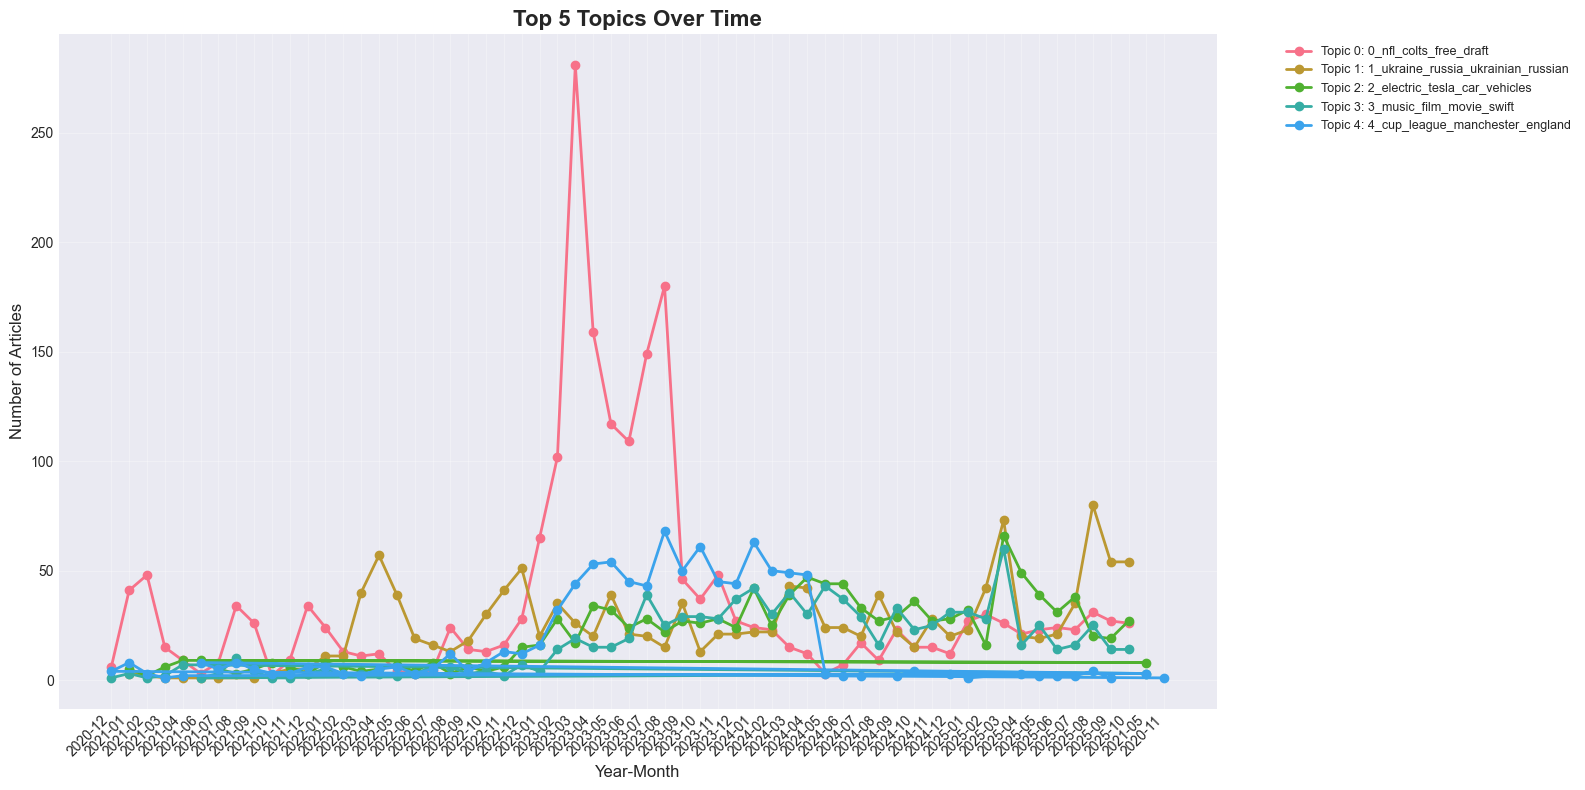

In [27]:
# Analyze topic distribution over time
print("\n\nTopic Trends Over Time:")
print("=" * 80)

# Get year-month for the sample
df_sample['year_month_str'] = df_sample['year_month'].astype(str)

# Top 5 topics by count
top_5_topics = topics_to_show.head(5)['Topic'].tolist()

topic_time = df_sample[df_sample['topic'].isin(top_5_topics)].groupby(['year_month_str', 'topic']).size().reset_index(name='count')

plt.figure(figsize=(16, 8))
for topic_id in top_5_topics:
    topic_data = topic_time[topic_time['topic'] == topic_id]
    topic_name = topic_info[topic_info['Topic'] == topic_id]['Name'].values[0]
    plt.plot(topic_data['year_month_str'], topic_data['count'], marker='o', label=f"Topic {topic_id}: {topic_name}", linewidth=2)

plt.title('Top 5 Topics Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Summary statistics
print("\n\nTopic Modeling Summary:")
print("=" * 80)
print(f"Total documents analyzed: {len(documents)}")
print(f"Total topics discovered: {len(topics_to_show)}")
print(f"Documents assigned to topics: {topics_to_show['Count'].sum()}")
print(f"Outliers (unassigned): {topic_info[topic_info['Topic'] == -1]['Count'].values[0] if len(topic_info[topic_info['Topic'] == -1]) > 0 else 0}")
print(f"Average documents per topic: {topics_to_show['Count'].mean():.1f}")
print(f"\nTop 5 topics:")
for idx, row in topics_to_show.head(5).iterrows():
    print(f"  {row['Name']}: {row['Count']} documents ({row['Count']/len(documents)*100:.1f}%)")


# CLEANUP
`See README.md`for full breakdown of methodology

In [28]:
# Words to filter out from headlines (case-insensitive)
words_to_filter = [
    'nfl', 'colts', 'bengals', 'chiefs', 'music', 'taylor', 
    'album', 'hollywood', 'chelsea', 'premier', 'football', 
    'stream', 'nba', 'lakers', 'celtics', '7634s', 'sixers'
]

print("Filtering out irrelevant news articles...")
print(f"Original dataset size: {len(df)} articles")

# Create a mask to identify articles with irrelevant headlines
# Check if title contains any of the filter words (case-insensitive)
filter_mask = df['title'].str.lower().str.contains('|'.join(words_to_filter), na=False, regex=True)

# Count articles to be removed
articles_to_remove = filter_mask.sum()
print(f"Articles to remove: {articles_to_remove} ({articles_to_remove/len(df)*100:.2f}%)")

# Filter the dataframe (keep articles that DON'T match the filter)
df_filtered = df[~filter_mask].copy()

print(f"Filtered dataset size: {len(df_filtered)} articles")
print(f"Articles removed: {len(df) - len(df_filtered)}")

# Show some examples of removed articles
print("\nSample of removed articles:")
removed_samples = df[filter_mask].head(5)
for idx, row in removed_samples.iterrows():
    print(f"  - {row['title']}")


Filtering out irrelevant news articles...
Original dataset size: 57169 articles
Articles to remove: 4020 (7.03%)
Filtered dataset size: 53149 articles
Articles removed: 4020

Sample of removed articles:
  - China gives musical talent show a virtual makeover
  - Arsenal 3-1 Chelsea: Chelsea 'lacked' energy and desire - Frank Lampard
  - Arsenal 3-1 Chelsea: Perfect Boxing Day or lazy afternoon?
  - Texans vs. Bengals: Time, TV schedule and streaming info for Week 16
  - Panthers vs. Washington: How to watch or stream Week 16 matchup


In [29]:
# Save the filtered dataset
output_filename = 'english_news_v1.csv'

# Select only the original columns (exclude computed columns like date, hour, year_month)
original_columns = ['publishedAt', 'title', 'source', 'description', 'url']
df_filtered_to_save = df_filtered[original_columns].copy()

# Save to CSV
df_filtered_to_save.to_csv(output_filename, index=False)

print(f"\nFiltered dataset saved as: {output_filename}")
print(f"Final dataset shape: {df_filtered_to_save.shape}")
print(f"Columns: {list(df_filtered_to_save.columns)}")



Filtered dataset saved as: english_news_v1.csv
Final dataset shape: (53149, 5)
Columns: ['publishedAt', 'title', 'source', 'description', 'url']


# Second Pass

In [30]:
# Prepare text data from filtered dataset
df_filtered_topic = df_filtered_to_save.copy()
df_filtered_topic['combined_text'] = df_filtered_topic.apply(
    lambda row: f"{row['title']} {row['description']}" 
    if pd.notna(row['title']) and pd.notna(row['description']) 
    else (row['title'] if pd.notna(row['title']) else str(row['description']) if pd.notna(row['description']) else ''),
    axis=1
)

# Remove empty strings and very short texts
df_filtered_topic = df_filtered_topic[df_filtered_topic['combined_text'].str.strip() != ''].copy()
df_filtered_topic = df_filtered_topic[df_filtered_topic['combined_text'].str.len() > 20].copy()

print(f"Articles prepared for topic modeling: {len(df_filtered_topic)}")
print(f"Average document length: {np.mean([len(doc) for doc in df_filtered_topic['combined_text']]):.1f} characters")

Articles prepared for topic modeling: 53148
Average document length: 217.2 characters


In [31]:
# Extract documents for topic modeling
documents_filtered = df_filtered_topic['combined_text'].tolist()

print(f"Total documents: {len(documents_filtered)}")

# Initialize BERTopic with the same settings as before
print("\nInitializing BERTopic model for filtered dataset...")
print("This may take a few minutes...")

# Use the same lightweight embedding model
embedding_model_filtered = SentenceTransformer('all-MiniLM-L6-v2')

# Configure dimensionality reduction and clustering (same settings)
umap_model_filtered = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model_filtered = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Initialize BERTopic
topic_model_filtered = BERTopic(
    embedding_model=embedding_model_filtered,
    umap_model=umap_model_filtered,
    hdbscan_model=hdbscan_model_filtered,
    top_n_words=10,
    verbose=True,
    language='english'
)

# Fit the model
print("\nFitting the model to filtered documents...")
topics_filtered, probs_filtered = topic_model_filtered.fit_transform(documents_filtered)

print(f"\nModel training completed!")
print(f"Number of topics discovered: {len(set(topics_filtered)) - (1 if -1 in topics_filtered else 0)}")
if -1 in topics_filtered:
    print(f"Outliers (topic -1): {topics_filtered.count(-1)} documents")


Total documents: 53148

Initializing BERTopic model for filtered dataset...
This may take a few minutes...


2025-10-31 13:02:08,388 - BERTopic - Embedding - Transforming documents to embeddings.



Fitting the model to filtered documents...


Batches: 100%|██████████| 1661/1661 [00:44<00:00, 37.06it/s]
2025-10-31 13:02:53,625 - BERTopic - Embedding - Completed ✓
2025-10-31 13:02:53,625 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-31 13:03:25,274 - BERTopic - Dimensionality - Completed ✓
2025-10-31 13:03:25,276 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR


Model training completed!
Number of topics discovered: 171
Outliers (topic -1): 20439 documents


In [32]:
# Get topic information and display top 20 topics
topic_info_filtered = topic_model_filtered.get_topic_info()

print("=" * 80)
print("TOP 20 TOPICS IN FILTERED DATASET")
print("=" * 80)

# Filter out outlier topic (-1) for display
topics_to_show_filtered = topic_info_filtered[topic_info_filtered['Topic'] != -1].head(20)

print(f"\nTotal topics discovered (excluding outliers): {len(topic_info_filtered[topic_info_filtered['Topic'] != -1])}")
print(f"Documents assigned to topics: {topics_to_show_filtered['Count'].sum()}")
if -1 in topics_filtered:
    outliers_count = topic_info_filtered[topic_info_filtered['Topic'] == -1]['Count'].values[0] if len(topic_info_filtered[topic_info_filtered['Topic'] == -1]) > 0 else 0
    print(f"Outliers (unassigned): {outliers_count}")

print("\n" + "=" * 80)
print(f"{'Rank':<6} {'Topic ID':<10} {'Articles':<12} {'Topic Name':<40} {'Key Words'}")
print("=" * 80)

for idx, (_, row) in enumerate(topics_to_show_filtered.iterrows(), 1):
    topic_id = row['Topic']
    count = row['Count']
    name = row['Name']
    
    # Get top words for this topic
    top_words = topic_model_filtered.get_topic(topic_id)
    words_str = ", ".join([word for word, score in top_words[:10]])
    
    # Shorten topic name if too long
    display_name = name[:37] + "..." if len(name) > 40 else name
    
    print(f"{idx:<6} {topic_id:<10} {count:<12} {display_name:<40} {words_str}")


TOP 20 TOPICS IN FILTERED DATASET

Total topics discovered (excluding outliers): 171
Documents assigned to topics: 13468
Outliers (unassigned): 20439

Rank   Topic ID   Articles     Topic Name                               Key Words
1      0          2378         0_ukraine_russia_russian_ukrainian       ukraine, russia, russian, ukrainian, putin, war, kyiv, sanctions, zelenskyy, moscow
2      1          1023         1_free_cowboys_bears_steelers            free, cowboys, bears, steelers, agent, rams, draft, saints, giants, eagles
3      2          945          2_mortgage_housing_home_rates            mortgage, housing, home, rates, average, rate, homes, homebuyers, market, estate
4      3          879          3_gaza_israel_hamas_israeli              gaza, israel, hamas, israeli, palestinian, palestinians, war, aid, hostages, lebanon
5      4          844          4_cup_league_manchester_england          cup, league, manchester, england, liverpool, arsenal, manager, win, champions, sid

In [33]:
# Detailed view of top 20 topics with more information
print("\n" + "=" * 80)
print("DETAILED TOP 20 TOPICS WITH KEYWORDS")
print("=" * 80)

for idx, (_, row) in enumerate(topics_to_show_filtered.iterrows(), 1):
    topic_id = row['Topic']
    count = row['Count']
    name = row['Name']
    
    # Get top words for this topic
    top_words = topic_model_filtered.get_topic(topic_id)
    
    print(f"\n{'─' * 80}")
    print(f"Rank {idx} | Topic {topic_id}: {name}")
    print(f"  Articles: {count} ({count/len(documents_filtered)*100:.2f}%)")
    print(f"  Top 10 keywords: {', '.join([word for word, score in top_words[:10]])}")
    print(f"  Keyword scores: {', '.join([f'{word}({score:.3f})' for word, score in top_words[:8]])}")



DETAILED TOP 20 TOPICS WITH KEYWORDS

────────────────────────────────────────────────────────────────────────────────
Rank 1 | Topic 0: 0_ukraine_russia_russian_ukrainian
  Articles: 2378 (4.47%)
  Top 10 keywords: ukraine, russia, russian, ukrainian, putin, war, kyiv, sanctions, zelenskyy, moscow
  Keyword scores: ukraine(0.045), russia(0.035), russian(0.030), ukrainian(0.021), putin(0.018), war(0.017), kyiv(0.013), sanctions(0.011)

────────────────────────────────────────────────────────────────────────────────
Rank 2 | Topic 1: 1_free_cowboys_bears_steelers
  Articles: 1023 (1.92%)
  Top 10 keywords: free, cowboys, bears, steelers, agent, rams, draft, saints, giants, eagles
  Keyword scores: free(0.027), cowboys(0.019), bears(0.019), steelers(0.018), agent(0.017), rams(0.017), draft(0.016), saints(0.014)

────────────────────────────────────────────────────────────────────────────────
Rank 3 | Topic 2: 2_mortgage_housing_home_rates
  Articles: 945 (1.78%)
  Top 10 keywords: mortg

# Second Cleanup

In [34]:
# ============================================
# SECOND ROUND OF FILTERING - REMOVE ADDITIONAL IRRELEVANT ARTICLES
# ============================================

# Additional words to filter out from headlines (case-insensitive)
additional_words_to_filter = [
    'cowboys', 'steelers', 'saints', 'giants', 'eagles', 'cup', 'league', 
    'arsenal', 'champions', 'film', 'movie', 'oscars', 'netfllix', 'festival', 
    'baribie', 'oscar', 'walmart', 'appliances', 'shooting', 'murder', 'shot'
]

print("Second round of filtering...")
print(f"Current dataset size (from english_news_v1): {len(df_filtered_to_save)} articles")

# Create a mask to identify articles with irrelevant headlines
# Check if title contains any of the additional filter words (case-insensitive)
filter_mask_v2 = df_filtered_to_save['title'].str.lower().str.contains('|'.join(additional_words_to_filter), na=False, regex=True)

# Count articles to be removed
articles_to_remove_v2 = filter_mask_v2.sum()
print(f"Articles to remove in this round: {articles_to_remove_v2} ({articles_to_remove_v2/len(df_filtered_to_save)*100:.2f}%)")

# Filter the dataframe (keep articles that DON'T match the filter)
df_filtered_v2 = df_filtered_to_save[~filter_mask_v2].copy()

print(f"Filtered dataset size (v2): {len(df_filtered_v2)} articles")
print(f"Total articles removed in this round: {len(df_filtered_to_save) - len(df_filtered_v2)}")
print(f"Total articles removed from original: {len(df) - len(df_filtered_v2)} ({(len(df) - len(df_filtered_v2))/len(df)*100:.2f}%)")

# Show some examples of removed articles
print("\nSample of removed articles (this round):")
removed_samples_v2 = df_filtered_to_save[filter_mask_v2].head(5)
for idx, row in removed_samples_v2.iterrows():
    print(f"  - {row['title']}")


Second round of filtering...
Current dataset size (from english_news_v1): 53149 articles
Articles to remove in this round: 1678 (3.16%)
Filtered dataset size (v2): 51471 articles
Total articles removed in this round: 1678
Total articles removed from original: 5698 (9.97%)

Sample of removed articles (this round):
  - Ravens vs. Giants final score tracker and instant analysis
  - Steelers WR JuJu Smith-Schuster admits the team had no energy in 1st half
  - Protesters demand answers in 1st Minneapolis police shooting death since George Floyd
  - Arsenal: From relegation fears to European hopes - how has Arteta turned team's form around?
  - Murder of Army vet at Iowa gas station one week before his wedding remains unsolved six decades later


In [35]:
# Save the second filtered dataset
output_filename_v2 = 'english_news_v2.csv'

# Save to CSV (already has the correct columns)
df_filtered_v2.to_csv(output_filename_v2, index=False)

print(f"\nSecond filtered dataset saved as: {output_filename_v2}")
print(f"Final dataset shape: {df_filtered_v2.shape}")
print(f"Columns: {list(df_filtered_v2.columns)}")
print(f"\nSummary:")
print(f"  Original dataset: {len(df)} articles")
print(f"  After first filter (v1): {len(df_filtered_to_save)} articles (removed {len(df) - len(df_filtered_to_save)} articles)")
print(f"  After second filter (v2): {len(df_filtered_v2)} articles (removed {len(df_filtered_to_save) - len(df_filtered_v2)} additional articles)")
print(f"  Total removed: {len(df) - len(df_filtered_v2)} articles ({(len(df) - len(df_filtered_v2))/len(df)*100:.2f}%)")



Second filtered dataset saved as: english_news_v2.csv
Final dataset shape: (51471, 5)
Columns: ['publishedAt', 'title', 'source', 'description', 'url']

Summary:
  Original dataset: 57169 articles
  After first filter (v1): 53149 articles (removed 4020 articles)
  After second filter (v2): 51471 articles (removed 1678 additional articles)
  Total removed: 5698 articles (9.97%)


# Third Pass

In [36]:
# Prepare text data from filtered v2 dataset
df_filtered_topic_v2 = df_filtered_v2.copy()
df_filtered_topic_v2['combined_text'] = df_filtered_topic_v2.apply(
    lambda row: f"{row['title']} {row['description']}" 
    if pd.notna(row['title']) and pd.notna(row['description']) 
    else (row['title'] if pd.notna(row['title']) else str(row['description']) if pd.notna(row['description']) else ''),
    axis=1
)

# Remove empty strings and very short texts
df_filtered_topic_v2 = df_filtered_topic_v2[df_filtered_topic_v2['combined_text'].str.strip() != ''].copy()
df_filtered_topic_v2 = df_filtered_topic_v2[df_filtered_topic_v2['combined_text'].str.len() > 20].copy()

print(f"Articles prepared for topic modeling (v2): {len(df_filtered_topic_v2)}")
print(f"Average document length: {np.mean([len(doc) for doc in df_filtered_topic_v2['combined_text']]):.1f} characters")


Articles prepared for topic modeling (v2): 51470
Average document length: 217.4 characters


In [37]:
# Extract documents for topic modeling
documents_filtered_v2 = df_filtered_topic_v2['combined_text'].tolist()

print(f"Total documents: {len(documents_filtered_v2)}")

# Initialize BERTopic with the same settings as before
print("\nInitializing BERTopic model for filtered v2 dataset...")
print("This may take a few minutes...")

# Use the same lightweight embedding model
embedding_model_filtered_v2 = SentenceTransformer('all-MiniLM-L6-v2')

# Configure dimensionality reduction and clustering (same settings)
umap_model_filtered_v2 = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model_filtered_v2 = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Initialize BERTopic
topic_model_filtered_v2 = BERTopic(
    embedding_model=embedding_model_filtered_v2,
    umap_model=umap_model_filtered_v2,
    hdbscan_model=hdbscan_model_filtered_v2,
    top_n_words=10,
    verbose=True,
    language='english'
)

# Fit the model
print("\nFitting the model to filtered v2 documents...")
topics_filtered_v2, probs_filtered_v2 = topic_model_filtered_v2.fit_transform(documents_filtered_v2)

print(f"\nModel training completed!")
print(f"Number of topics discovered: {len(set(topics_filtered_v2)) - (1 if -1 in topics_filtered_v2 else 0)}")
if -1 in topics_filtered_v2:
    print(f"Outliers (topic -1): {topics_filtered_v2.count(-1)} documents")


Total documents: 51470

Initializing BERTopic model for filtered v2 dataset...
This may take a few minutes...


2025-10-31 13:18:29,404 - BERTopic - Embedding - Transforming documents to embeddings.



Fitting the model to filtered v2 documents...


Batches: 100%|██████████| 1609/1609 [00:42<00:00, 38.07it/s]
2025-10-31 13:19:12,378 - BERTopic - Embedding - Completed ✓
2025-10-31 13:19:12,379 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-31 13:19:42,362 - BERTopic - Dimensionality - Completed ✓
2025-10-31 13:19:42,363 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR


Model training completed!
Number of topics discovered: 164
Outliers (topic -1): 20477 documents


In [40]:
# Get topic information and display top 20 topics
topic_info_filtered_v2 = topic_model_filtered_v2.get_topic_info()

print("=" * 80)
print("TOP 20 TOPICS IN FILTERED DATASET V2")
print("=" * 80)

# Filter out outlier topic (-1) for display
topics_to_show_filtered_v2 = topic_info_filtered_v2[topic_info_filtered_v2['Topic'] != -1].head(50)

print(f"\nTotal topics discovered (excluding outliers): {len(topic_info_filtered_v2[topic_info_filtered_v2['Topic'] != -1])}")
print(f"Documents assigned to topics: {topics_to_show_filtered_v2['Count'].sum()}")
if -1 in topics_filtered_v2:
    outliers_count_v2 = topic_info_filtered_v2[topic_info_filtered_v2['Topic'] == -1]['Count'].values[0] if len(topic_info_filtered_v2[topic_info_filtered_v2['Topic'] == -1]) > 0 else 0
    print(f"Outliers (unassigned): {outliers_count_v2}")

print("\n" + "=" * 80)
print(f"{'Rank':<6} {'Topic ID':<10} {'Articles':<12} {'Topic Name':<40} {'Key Words'}")
print("=" * 80)

for idx, (_, row) in enumerate(topics_to_show_filtered_v2.iterrows(), 1):
    topic_id = row['Topic']
    count = row['Count']
    name = row['Name']
    
    # Get top words for this topic
    top_words = topic_model_filtered_v2.get_topic(topic_id)
    words_str = ", ".join([word for word, score in top_words[:10]])
    
    # Shorten topic name if too long
    display_name = name[:37] + "..." if len(name) > 40 else name
    
    print(f"{idx:<6} {topic_id:<10} {count:<12} {display_name:<40} {words_str}")


TOP 20 TOPICS IN FILTERED DATASET V2

Total topics discovered (excluding outliers): 164
Documents assigned to topics: 19813
Outliers (unassigned): 20477

Rank   Topic ID   Articles     Topic Name                               Key Words
1      0          2364         0_ukraine_russia_russian_ukrainian       ukraine, russia, russian, ukrainian, putin, war, kyiv, sanctions, zelenskyy, moscow
2      1          929          1_mortgage_housing_home_rates            mortgage, housing, home, rates, average, rate, homes, homebuyers, market, level
3      2          870          2_gaza_israel_hamas_israeli              gaza, israel, hamas, israeli, palestinian, palestinians, war, aid, lebanon, hostages
4      3          694          3_free_bears_rams_draft                  free, bears, rams, draft, agent, packers, texans, lions, offseason, 49ers
5      4          677          4_china_xi_chinese_trade                 china, xi, chinese, trade, beijing, jinping, tariffs, ties, president, us
6      

In [41]:
# Detailed view of top 20 topics with more information
print("\n" + "=" * 80)
print("DETAILED TOP 50 TOPICS WITH KEYWORDS (V2 DATASET)")
print("=" * 80)

for idx, (_, row) in enumerate(topics_to_show_filtered_v2.iterrows(), 1):
    topic_id = row['Topic']
    count = row['Count']
    name = row['Name']
    
    # Get top words for this topic
    top_words = topic_model_filtered_v2.get_topic(topic_id)
    
    print(f"\n{'─' * 80}")
    print(f"Rank {idx} | Topic {topic_id}: {name}")
    print(f"  Articles: {count} ({count/len(documents_filtered_v2)*100:.2f}%)")
    print(f"  Top 10 keywords: {', '.join([word for word, score in top_words[:10]])}")
    print(f"  Keyword scores: {', '.join([f'{word}({score:.3f})' for word, score in top_words[:8]])}")



DETAILED TOP 50 TOPICS WITH KEYWORDS (V2 DATASET)

────────────────────────────────────────────────────────────────────────────────
Rank 1 | Topic 0: 0_ukraine_russia_russian_ukrainian
  Articles: 2364 (4.59%)
  Top 10 keywords: ukraine, russia, russian, ukrainian, putin, war, kyiv, sanctions, zelenskyy, moscow
  Keyword scores: ukraine(0.045), russia(0.036), russian(0.030), ukrainian(0.020), putin(0.018), war(0.018), kyiv(0.013), sanctions(0.011)

────────────────────────────────────────────────────────────────────────────────
Rank 2 | Topic 1: 1_mortgage_housing_home_rates
  Articles: 929 (1.80%)
  Top 10 keywords: mortgage, housing, home, rates, average, rate, homes, homebuyers, market, level
  Keyword scores: mortgage(0.059), housing(0.032), home(0.031), rates(0.028), average(0.021), rate(0.018), homes(0.017), homebuyers(0.015)

────────────────────────────────────────────────────────────────────────────────
Rank 3 | Topic 2: 2_gaza_israel_hamas_israeli
  Articles: 870 (1.69%)
  T

# Third Clean Up

In [42]:
# Final set of words to filter out from headlines (case-insensitive)
final_words_to_filter = [
    'bears', 'rams', 'packers', 'texans', 'lions', 'offseason', '49ers', 
    'manchester', 'liverpool', 'league', 'celtic', 'fashion', 'movie', 
    'pop', 'star', 'netflix', 'film', 'drama', 'best deals', 'best deal', 
    'amazon', 'sale', 'football', 'usc', 'college', 'penn', 'coffee', 
    'starbucks', 'beer', 'alcohol', 'soda', 'caffeine', 'coca', 'cola', 
    'ufc', 'mma', 'champ', 'pereira', 'makachev', 'telescope', 'nasa', 
    'astronomer', 'webb', 'eclipse', 'olympic', 'olympics', 'marathon', 
    'medal', 'swimming', 'sport', 'skin', 'hair', 'dermatologists', 
    'sunscreen', 'police', 'bangladesh', 'nets', 'bulls', 'rockets', 
    'lebron', 'warriors', 'nba', 'dog', 'zoo', 'bear', 'dogs', 'cat', 
    'retriever', 'animals', 'eagle', 'holiday', 'shoppers', 'shopping'
]

print("Final round of filtering...")
print(f"Current dataset size (from english_news_v2): {len(df_filtered_v2)} articles")

# Create a mask to identify articles with irrelevant headlines
# Check if title contains any of the final filter words (case-insensitive)
filter_mask_v3 = df_filtered_v2['title'].str.lower().str.contains('|'.join(final_words_to_filter), na=False, regex=True)

# Count articles to be removed
articles_to_remove_v3 = filter_mask_v3.sum()
print(f"Articles to remove in this round: {articles_to_remove_v3} ({articles_to_remove_v3/len(df_filtered_v2)*100:.2f}%)")

# Filter the dataframe (keep articles that DON'T match the filter)
df_filtered_v3 = df_filtered_v2[~filter_mask_v3].copy()

print(f"Filtered dataset size (v3): {len(df_filtered_v3)} articles")
print(f"Total articles removed in this round: {len(df_filtered_v2) - len(df_filtered_v3)}")
print(f"Total articles removed from original: {len(df) - len(df_filtered_v3)} ({(len(df) - len(df_filtered_v3))/len(df)*100:.2f}%)")

# Show some examples of removed articles
print("\nSample of removed articles (this round):")
removed_samples_v3 = df_filtered_v2[filter_mask_v3].head(5)
for idx, row in removed_samples_v3.iterrows():
    print(f"  - {row['title']}")


Final round of filtering...
Current dataset size (from english_news_v2): 51471 articles
Articles to remove in this round: 7092 (13.78%)
Filtered dataset size (v3): 44379 articles
Total articles removed in this round: 7092
Total articles removed from original: 12790 (22.37%)

Sample of removed articles (this round):
  - Peru impeachment protests: Clashes with police with police turn deadly
  - Sentinel-6: 'Dog kennel' satellite to measure sea-level rise
  - Reports: Biden picks Janet Yellen, former Fed chair, as first woman to lead Treasury Department
  - France: Tear gas fired as protesters rally against police security bill
  - Paris: Tear gas and fires at protest against police violence


In [43]:
# Save the final filtered dataset
output_filename_v3 = 'english_news_v3.csv'

# Save to CSV (already has the correct columns)
df_filtered_v3.to_csv(output_filename_v3, index=False)

print(f"\nFinal filtered dataset saved as: {output_filename_v3}")
print(f"Final dataset shape: {df_filtered_v3.shape}")
print(f"Columns: {list(df_filtered_v3.columns)}")
print(f"\nComplete Summary:")
print(f"  Original dataset: {len(df)} articles")
print(f"  After first filter (v1): {len(df_filtered_to_save)} articles (removed {len(df) - len(df_filtered_to_save)} articles)")
print(f"  After second filter (v2): {len(df_filtered_v2)} articles (removed {len(df_filtered_to_save) - len(df_filtered_v2)} additional articles)")
print(f"  After third filter (v3): {len(df_filtered_v3)} articles (removed {len(df_filtered_v2) - len(df_filtered_v3)} additional articles)")
print(f"  Total removed from original: {len(df) - len(df_filtered_v3)} articles ({(len(df) - len(df_filtered_v3))/len(df)*100:.2f}%)")
print(f"  Final dataset retained: {len(df_filtered_v3)} articles ({(len(df_filtered_v3)/len(df)*100):.2f}%)")



Final filtered dataset saved as: english_news_v3.csv
Final dataset shape: (44379, 5)
Columns: ['publishedAt', 'title', 'source', 'description', 'url']

Complete Summary:
  Original dataset: 57169 articles
  After first filter (v1): 53149 articles (removed 4020 articles)
  After second filter (v2): 51471 articles (removed 1678 additional articles)
  After third filter (v3): 44379 articles (removed 7092 additional articles)
  Total removed from original: 12790 articles (22.37%)
  Final dataset retained: 44379 articles (77.63%)
